## Celem tego notebooka jest pre-processing danych zebranych przez scraper, a następnie ich analiza.

### Import bibliotek

In [51]:
import pandas as pd
import plotly
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter
from wordcloud import WordCloud

### Wczytanie danych

In [33]:
df = pd.read_csv("data/csv/lubimy_czytac_top100_pl.csv")
df.head()

,okres,tytuł,autor,pozycja_w_rankingu,zmiana_w_rankingu,ocena,liczba_ocen,liczba_czytelników,liczba_recenzji
0,04-2026,Szczęście czy fart?,"Trias de Bes Fernando,Alex Rovira Celma",1,⬈,"7,4",359,1395,42
1,04-2026,Projekt Hail Mary,Andy Weir,2,⬊,"8,1",7450,14356,1269
2,04-2026,Święto Karkonoszy,Sławek Gortych,3,★,"7,7",681,2401,147
3,04-2026,Cały ten błękit,Mélissa Da Costa,4,⬊,"7,8",2948,8801,560
4,04-2026,Gołoborze,Maciej Siembieda,5,⬊,"8,3",4219,9777,872


### Podstawowe informacje o zbiorze danych

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   okres               1468 non-null   str  
 1   tytuł               1468 non-null   str  
 2   autor               1468 non-null   str  
 3   pozycja_w_rankingu  1468 non-null   int64
 4   zmiana_w_rankingu   1468 non-null   str  
 5   ocena               1468 non-null   str  
 6   liczba_ocen         1468 non-null   int64
 7   liczba_czytelników  1468 non-null   int64
 8   liczba_recenzji     1468 non-null   int64
dtypes: int64(4), str(5)
memory usage: 103.3 KB


#### Ze wstępnej analizy wynika, że zbiór danych jest komplentny, nie zawiera brakujących wartości, typy danych w kolumnie 'ocena' natomiast są nieodpowiednie i należy je zmienić. Pondadto wartości w kolumnie 'zmiana_w_rankingu' należy przekształcić, aby były bardziej czytelne (opisowe zamiast ikonek).

In [35]:
df['ocena'] = df['ocena'].str.replace(',', '.').astype(float)
df = df.rename(columns={"tytuł": "tytul"})
df = df.rename(columns={"liczba_czytelników": "liczba_czytelnikow"})
# Przekształcenie wartości zgodne z legendą lubimyczytać.pl (★ - nowość, ⬈ - awans, ⬊ - spadek, ⬌ - bez zmian)
df["zmiana_w_rankingu"] = df["zmiana_w_rankingu"].replace({
    "★": "nowosc",
    "⬈": "awans",
    "⬊": "spadek",
    "⬌": "bez-zmian"
})

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   okres               1468 non-null   str    
 1   tytul               1468 non-null   str    
 2   autor               1468 non-null   str    
 3   pozycja_w_rankingu  1468 non-null   int64  
 4   zmiana_w_rankingu   1468 non-null   str    
 5   ocena               1468 non-null   float64
 6   liczba_ocen         1468 non-null   int64  
 7   liczba_czytelnikow  1468 non-null   int64  
 8   liczba_recenzji     1468 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 103.3 KB


In [37]:
df.head()

,okres,tytul,autor,pozycja_w_rankingu,zmiana_w_rankingu,ocena,liczba_ocen,liczba_czytelnikow,liczba_recenzji
0,04-2026,Szczęście czy fart?,"Trias de Bes Fernando,Alex Rovira Celma",1,awans,7.4,359,1395,42
1,04-2026,Projekt Hail Mary,Andy Weir,2,spadek,8.1,7450,14356,1269
2,04-2026,Święto Karkonoszy,Sławek Gortych,3,nowosc,7.7,681,2401,147
3,04-2026,Cały ten błękit,Mélissa Da Costa,4,spadek,7.8,2948,8801,560
4,04-2026,Gołoborze,Maciej Siembieda,5,spadek,8.3,4219,9777,872


In [38]:
df['zmiana_w_rankingu'].value_counts()

zmiana_w_rankingu
nowosc       569
spadek       511
awans        368
bez-zmian     20
Name: count, dtype: int64

In [39]:
### Zapis danych do csv
df.to_csv("data/csv/lubimy_czytac_top100_pl_preprocessed.csv", index=False)

In [40]:
df['okres'].value_counts()

okres
06-2025    130
11-2025    128
08-2025    127
10-2025    126
07-2025    126
01-2026    125
05-2025    123
09-2025    122
12-2025    119
03-2026    117
02-2026    113
04-2026    112
Name: count, dtype: int64

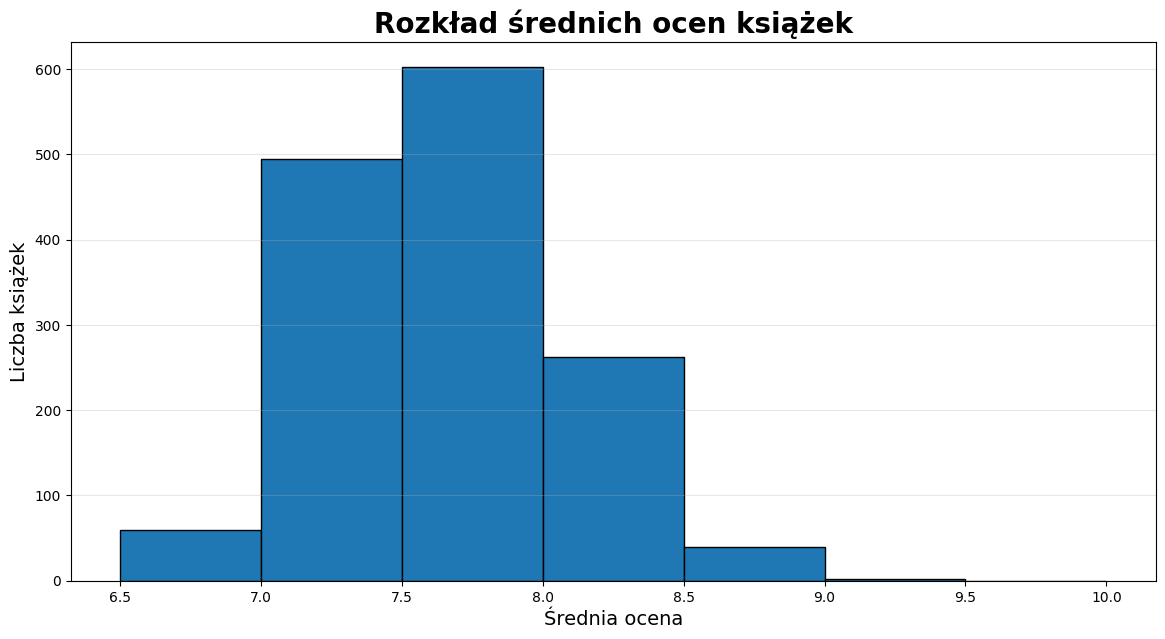

In [54]:
plt.figure(figsize=(14, 7))

plt.hist(df["ocena"], bins=[6.5, 7, 7.5, 8,8.5, 9, 9.5, 10], edgecolor="black")

plt.title("Rozkład średnich ocen książek", fontsize=20, fontweight="bold")
plt.xlabel("Średnia ocena", fontsize=14)
plt.ylabel("Liczba książek", fontsize=14)

 
plt.grid(axis="y", alpha=0.3)

plt.show()

### 1. Bubble chart - ocena vs liczba czytelników, popularność książek

In [42]:

fig = px.scatter(
    df,
    x='liczba_ocen',
    y='ocena',
    size='liczba_czytelnikow',
    color='pozycja_w_rankingu',
    hover_name='tytul',
    hover_data=['autor'],
    title='Popularność książek',
    size_max=60
)

fig.update_layout(
    template='plotly_dark',
    height=700
)

fig.show()

### Popularność tytułów (większy rozmiar oznacza większą popularność)

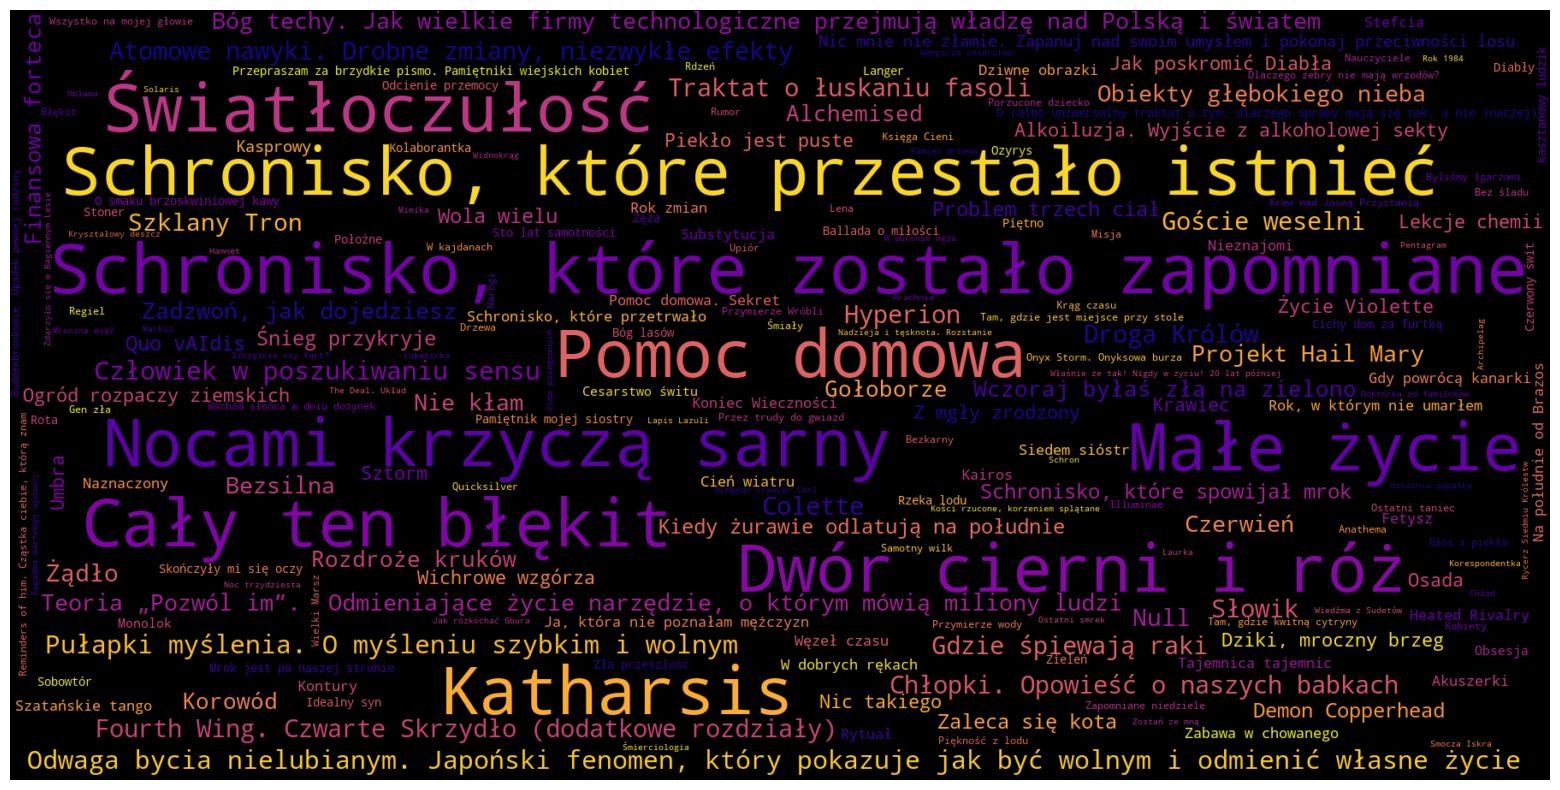

In [52]:
# Liczenie wystąpień tytułów
title_counts = Counter(df["tytul"])

# Wordcloud z pełnych tytułów
wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="black",
    colormap="plasma"
).generate_from_frequencies(title_counts)

plt.figure(figsize=(20, 10))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.show()